In [129]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

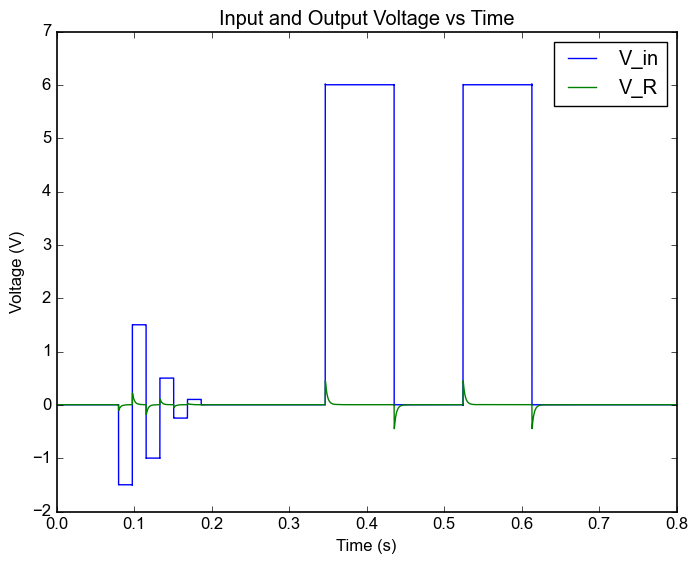

100000.00000000001


In [130]:
data = np.loadtxt("./Data/20262704001.dat")

R = 100e3  # Resistance in ohms

t = data[:, 0]
V_R = data[:, 1]
main_trigger = data[:, 2]
V_in = data[:, 3]
second_trigger = data[:, 4]
I = data[:, 5]
V_C = V_in - V_R

plt.plot(t, V_in, label='V_in')
plt.plot(t, V_R, label='V_R')
# plt.plot(t, V_C, label='V_C')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
# plt.xlim(0.02, 0.22)

plt.title('Input and Output Voltage vs Time')
plt.legend()
plt.show()

print(V_R[8]/I[8])

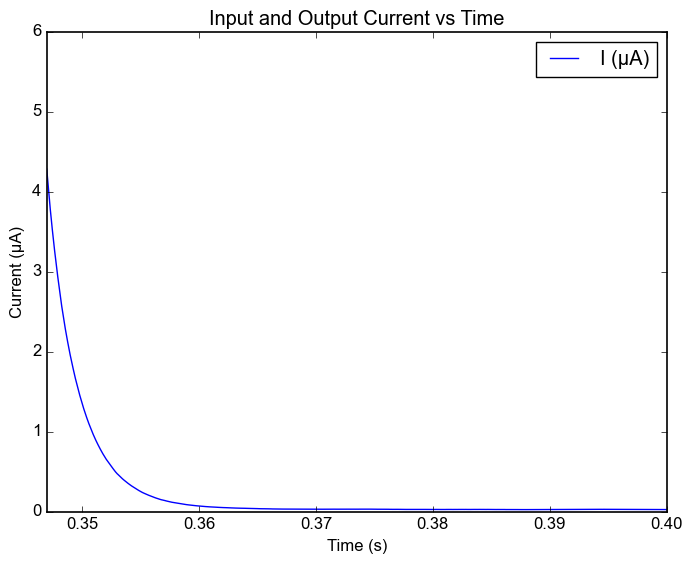

In [131]:
plt.plot(t, I*1e6, label='I (µA)')
# plt.plot(t, V_C, label='V_C')
plt.xlabel('Time (s)')
plt.ylabel('Current (µA)')
plt.xlim(0.347, 0.4)
plt.ylim(0, 6)
plt.title('Input and Output Current vs Time')
plt.legend()
plt.show()

a = 0.402 ± 5e+04
b = 0.316 ± 335
c = 0.0027 ± 3.24e-06
R^2 = 0.999
C = (2.7e-08 ± 3.24e-11) F


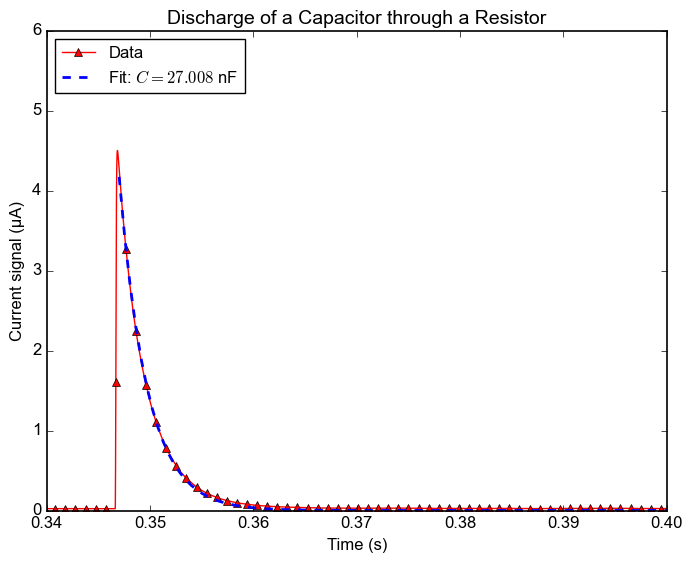

In [132]:
def func(x, a, b, c):
    return a * np.exp(-(x-b) / c)

mask = np.isfinite(t) & np.isfinite(I) & (t >= 0.347) & (t <= 0.355)
popt, pcov = curve_fit(func, t[mask], I[mask])
sigma_fit = func(t[mask], *popt)
a, b, c = popt

# Coefficient of determination
ss_res = np.sum((I[mask] - sigma_fit) ** 2)
ss_tot = np.sum((I[mask] - np.mean(I[mask])) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err, c_err = perr
C = c / R
C_err = c_err / R

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"c = {c:.3g} ± {c_err:.3g}")
print(f"R^2 = {r2:.3f}")

print(f"C = ({C:.3g} ± {C_err:.3g}) F")

x = np.linspace(0.347, 0.4, 100)
plt.plot(t, I*1e6, '^', label='Data', color='red', markersize=6, linestyle='-', markevery=100)
plt.plot(x, func(x, *popt) * 1e6, lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (s)")
plt.ylabel(r"Current signal (µA)")
plt.xlim(0.34, 0.4)
plt.ylim(0, 6)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=12)
plt.title("Discharge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()